# Lab 1-2 - Środowisko Programistyczne + Wprowadzenie do uczenia maszynowego

## Konfiguracja środowiska programistycznego
### Google Colab: https://colab.research.google.com/github/yy/dviz-course/blob/master/docs/m01-intro/lab01.ipynb
### Pycharm: https://www.jetbrains.com/help/pycharm/creating-virtual-environment.html

## Przydatne linki

### Integracja Colab-GitHub: https://colab.research.google.com/github/googlecolab/colabtools/blob/master/notebooks/colab-github-demo.ipynb

### Synchronizacja Pycharm-Github: https://www.jetbrains.com/help/pycharm/github.html

### Podstawy operacji na ramkach danych w Pandas: https://www.kaggle.com/learn/pandas

### Tworzenie wykresów w seaborn: https://www.kaggle.com/code/vijayjoshi17/seaborn-guide-all-important-plots

# Zadania:



## Ocena zadań
### Zasady oceniania dla listy 1:
Student w ciągu 5-6 minut prezentuje i omawia napisany przez siebie kod, a następnie prowadzący zadaje 1-2 pytania do całości listy w celu werfikacji czy student rozumie kod, który zaprezentował.

Za każde zadanie można dostać maksymalnie 2 punkty.

### Ocena jest redukowana o 1 punkt w przypadku:
- niepełnej realizacji polecenia (np. brak jednego z podpunktów)
- niezdolności do odpowiedzi na pytanie ze zrozumienia kodu
- popełnienia błędu w kodzie

## Wykorzystywane zbiory danych
Poniższa lista zadań wykorzystuje dwa zbiory danych dostępne na platformie Kaggle:

### Dla zadań 1-4:

Student Lifestyle and Academic Performance Dataset: https://www.kaggle.com/datasets/sehaj1104/student-lifestyle-and-academic-performance-dataset

### Dla zadania nr 5:

Social Media Viral Content and Engagement Metrics: https://www.kaggle.com/datasets/aliiihussain/social-media-viral-content-and-engagement-metrics

## Dokumentacje bibliotek potrzebnych do realizacji zadań:
- pandas: https://pandas.pydata.org/docs/index.html
- seaborn: https://seaborn.pydata.org/
- matplotlib: https://matplotlib.org/stable/


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data1 = pd.read_csv('/content/student_lifestyle_performance_dataset.csv')
data5 = pd.read_csv('/content/social_media_viral_content_dataset.csv')

## Zadanie 1
Wyświetl ramkę danych spełniającą następujące kryteria:
- ramka zawiera wyłącznie informacje o wieku studentów oraz tym jak spędzają czas.
- ramka zawiera informacje wyłącznie o 15 studentach z najwyższą średnią (CGPA)
- ramka jest posortowana pod względem średniej, tak by student z najwyższą średnią był wyświetlany jako pierwszy

In [ ]:
time_use = data1.sort_values(by='CGPA', ascending=False).head(15)
time_use[['Age', 'Study_Hours_per_Day', 'Sleep_Hours', 'Screen_Time_Hours', 'Gym_Hours_per_Week']]

,Age,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week
657,22,6.85,8.45,3.84,12.67
109,23,5.83,9.26,7.19,6.05
843,24,4.64,8.34,3.28,3.59
405,17,6.87,7.92,2.21,18.13
464,25,5.18,9.13,7.92,7.85
171,20,8.05,7.34,6.46,0.00
475,19,5.71,8.07,2.98,12.96
639,19,7.30,8.57,3.96,8.24
659,20,3.85,9.22,7.14,5.21
682,25,4.87,8.25,4.95,0.00


## Zadanie 2
dodaj do ramki danych kolumnę z wyliczoną średnią ilością czasu wolnego, którym student dysponuje w ciągu dnia.


### Wyliczając wartość czasu wolnego przyjmij następujące założenia:
- czas wolny studenta to cały czas, którego **NIE** poświęca na naukę, ćwiczenia, sen oraz siedzenie przed ekranem oraz na jedzenie i czynności higieniczne
- około godzina czasu spędzonego przed ekranem to czas poświęcony na naukę
- jedzenie i czynności higieniczne zajmują przeciętnej osobie 2,5 godziny w ciągu dnia

### Następnie wyświetl otrzymaną ramkę danych tak, by spełniała następujące kryteria:
- wyświetl wyłącznie dodatkową kolumnę oraz kolumny wykorzystane do wyliczenia ilości czasu wolnego
- kolumna z czasem wolnym powinna wyświetlać się jako pierwsza z lewej
- czas wolny powinien być zaokrąglony do drugiej liczby po przecinku

In [6]:
spare_time = data1.copy()
spare_time['Gym_Hours_per_Day'] = spare_time['Gym_Hours_per_Week'] / 7
spare_time['Gym_Hours_per_Day'] = spare_time['Gym_Hours_per_Day'].round(2)
spare_time['Spare_Time'] = 22 - (spare_time['Study_Hours_per_Day'] + spare_time['Sleep_Hours'] + spare_time['Screen_Time_Hours'] + spare_time['Gym_Hours_per_Day'])
spare_time['Spare_Time'] = spare_time['Spare_Time'].round(2)
spare_time.loc[:, ['Spare_Time', 'Gym_Hours_per_Day', 'Study_Hours_per_Day', 'Sleep_Hours', 'Screen_Time_Hours']]
# print(spare_time.loc[:, ['Spare_Time', 'Gym_Hours_per_Day', 'Study_Hours_per_Day', 'Sleep_Hours', 'Screen_Time_Hours']])

,Spare_Time,Gym_Hours_per_Day,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours
0,1.41,0.38,4.14,6.84,9.23
1,5.19,2.23,5.97,5.52,3.09
2,10.04,0.36,3.19,3.39,5.02
3,1.58,0.00,4.77,6.44,9.21
4,3.86,1.42,5.42,6.54,4.76
...,...,...,...,...,...
995,6.10,1.81,4.60,5.26,4.23
996,7.14,0.41,4.02,6.55,3.88
997,4.65,0.00,4.28,8.43,4.64
998,3.24,1.44,6.42,6.06,4.84


## Zadanie 3
utwórz ramkę danych pozwalającą odpowiedzieć na następujące pytania
- Jaka dziedzina naukowa (*Branch*) jest najbardziej stresująca?
- Czy mediana snu wśród studentów informatyki (*IT*) jest wyższa niż wśród studentów mechaniki (*Mechanical*)?
### UWAGA!
Uwzględnij wyłącznie informacje o pełnoletnich studentach.

In [5]:
stress = data1.copy()
stress = stress[stress['Age'] >= 18].loc[:, ['Branch', 'Sleep_Hours', 'Stress_Level_1_to_10']]
stress = stress.groupby('Branch').median()
stress = stress.sort_values(by='Stress_Level_1_to_10', ascending=False)
stress

,Sleep_Hours,Stress_Level_1_to_10
Branch,,
Civil,6.710,4.785
ECE,6.405,4.615
Mechanical,6.640,4.520
IT,6.755,4.480
Electrical,6.310,4.355
CSE,6.540,4.330


## Zadanie 4
Przedstaw na wykresach:
- zależność między czasem snu a osiąganą średnią z uwzględnieniem diety studenta
- średnią obecność na zajęciach dla poszczególnych dziedzin naukowych
### UWAGA!
potraktuj informatykę (*IT*) i inżynierię komputerową (*CSE*) jako jedną dziedzinę

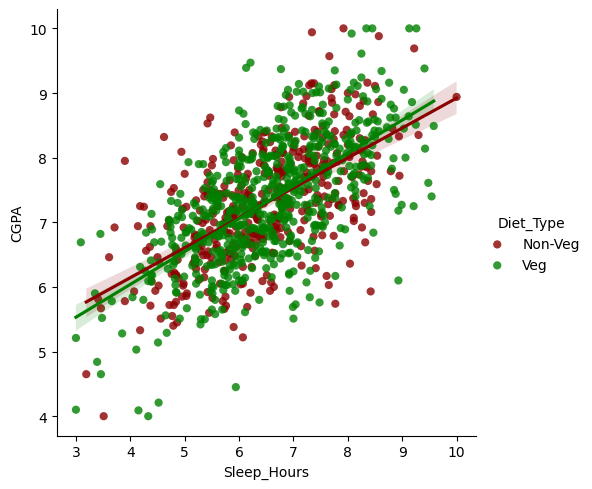

In [ ]:
data4 = data1.copy()
sns.lmplot(data=data4, x='Sleep_Hours', y='CGPA', hue='Diet_Type', palette={'Veg':"green", 'Non-Veg':'darkred'}, scatter_kws={'s':35, 'edgecolors':'none'})

/tmp/ipykernel_314/3166014330.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data4['Branch'].replace(to_replace=['IT', 'CSE'], value='IT+CSE', inplace=True)


<Axes: xlabel='Branch', ylabel='Attendance_Percentage'>

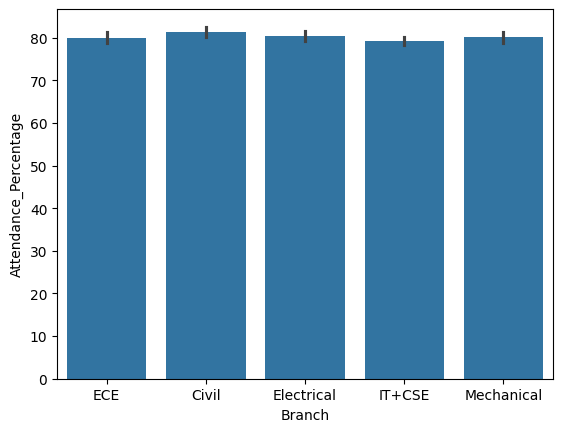

In [ ]:
data4['Branch'].replace(to_replace=['IT', 'CSE'], value='IT+CSE', inplace=True)
data4.groupby('Branch')['Attendance_Percentage'].mean()
sns.barplot(data=data4, x='Branch', y='Attendance_Percentage')

## Zadanie 5:
Utwórz wykresy, które pozwalają przedstawić następujące informacje:
- Najpopularniejsze tematy filmów na YouTube Shorts w ostatnim kwartale 2024 roku
- Jaki hasztag najbardziej opłaca się umieszczać w  postach na poszczególnych platformach?

<Axes: title={'center': 'The most popular topics of the IV quarter'}, xlabel='views', ylabel='topic'>

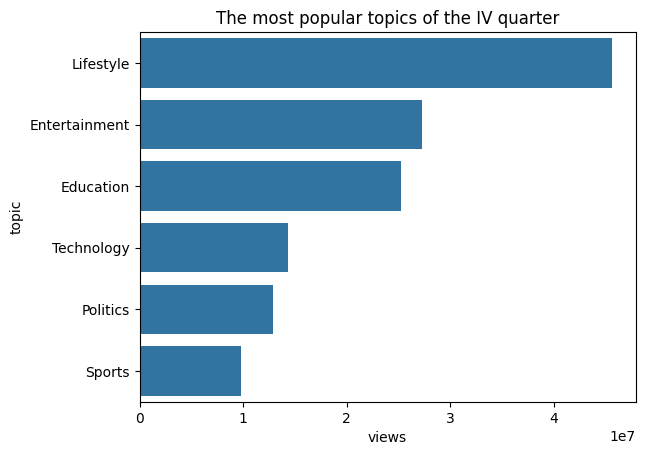

In [4]:
data5_1 = data5.copy()
yt_shorts = data5_1['platform'] == 'YouTube Shorts'
video = data5_1['content_type'] == 'video'
data5_1['post_datetime'] = pd.to_datetime(data5_1['post_datetime'])
data5_1['quarter'] = data5_1['post_datetime'].dt.quarter
data5_1['year'] = data5_1['post_datetime'].dt.year
q4 = (data5_1['quarter'] == 4) & (data5_1['year'] == 2024)
most_popular = data5_1[yt_shorts & q4 & video]
most_popular = most_popular.groupby('topic')['views'].sum().reset_index()
most_popular = most_popular.sort_values(by='views', ascending=False)
plt.title('The most popular topics of the IV quarter')
sns.barplot(data=most_popular, x='views', y='topic')

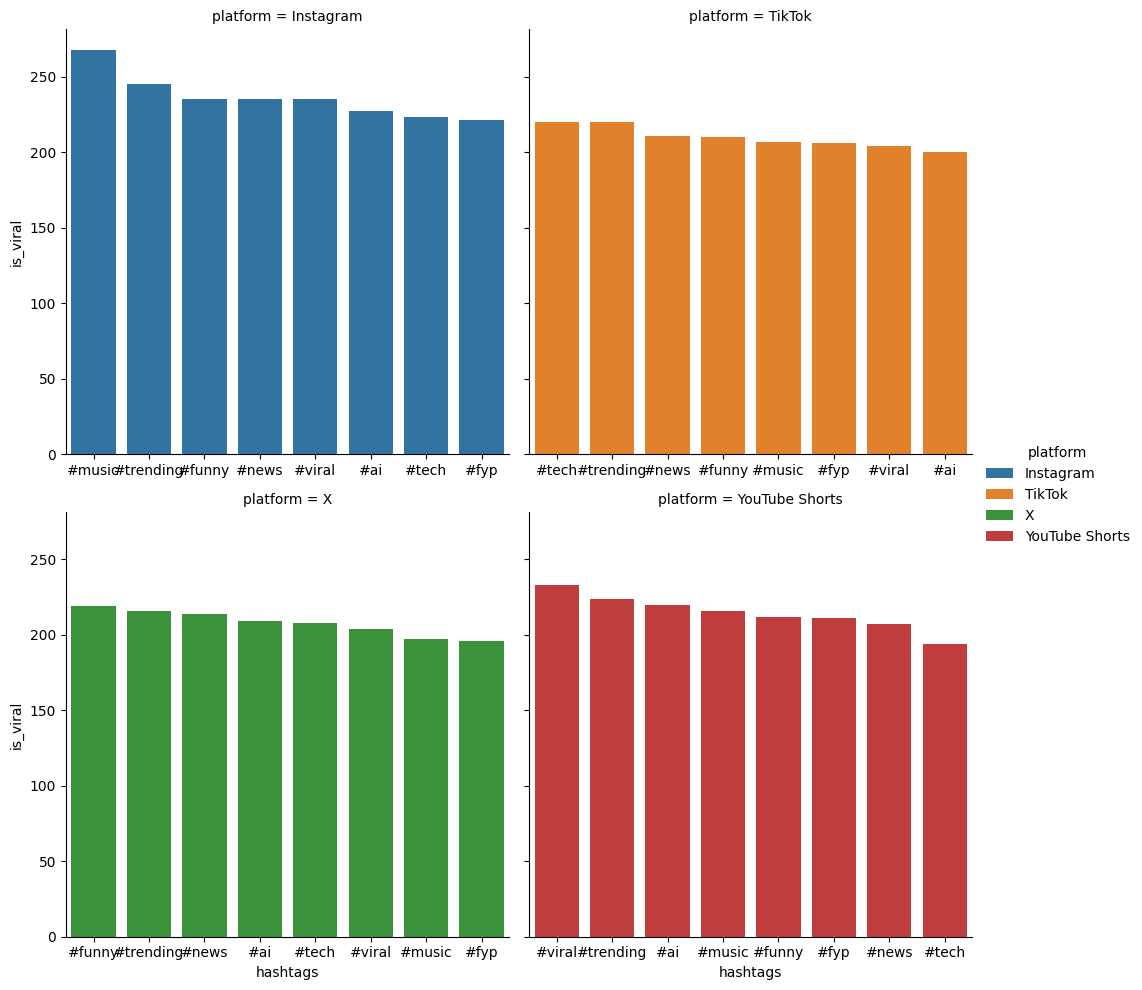

In [ ]:
data5_2 = data5.copy()
data5_2['hashtags'] = data5_2['hashtags'].str.split()
data5_2 = data5_2.explode('hashtags')
data5_2 = data5_2.groupby(['platform', 'hashtags'])['is_viral'].count().reset_index()
data5_2 = data5_2.sort_values(by=['platform' ,'is_viral'], ascending=[True, False])
sns.catplot(data=data5_2, x='hashtags', y='is_viral', col='platform', hue='platform', col_wrap=2, kind='bar', sharex=False)